# VisionGuard AI — MVTec AD Dataset Preparation

A clean VS Code / Jupyter notebook for downloading, preparing, validating, analyzing, and visualizing five MVTec AD categories.

**Categories:** `screw` · `bottle` · `capsule` · `metal_nut` · `hazelnut`


## Workflow

1. Install dependencies
2. Import libraries
3. Download MVTec AD
4. Detect the dataset automatically
5. Select the five required categories
6. Validate the dataset structure
7. Count and summarize images
8. Discover defect classes
9. Audit image properties
10. Generate visualizations
11. Save every visualization as a titled PNG
12. Run final validation


## Installation

In [1]:
%pip install -q -U kagglehub pandas numpy matplotlib "plotly[kaleido]" pillow ipykernel nbformat


Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
from pathlib import Path
import re
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image, UnidentifiedImageError
from IPython.display import display

import kagglehub
import nbformat

warnings.filterwarnings("ignore")


/home/as178/VisionGuard-AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut",
]

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
}

KAGGLE_DATASET = "ipythonx/mvtec-ad"

PROJECT_ROOT = Path.cwd().resolve()
PREPARED_DATASET = PROJECT_ROOT / "visionguard_data"
IMAGE_FOLDER = PROJECT_ROOT / "images"

IMAGE_FOLDER.mkdir(parents=True, exist_ok=True)

print("Requested categories:", ", ".join(CATEGORIES))

Requested categories: screw, bottle, capsule, metal_nut, hazelnut


## Visualization Export Utilities

In [4]:
def safe_image_name(name):
    name = re.sub(r"<[^>]+>", "", str(name))
    name = re.sub(r"[^A-Za-z0-9\s_-]", "", name)
    name = re.sub(r"\s+", "_", name.strip())
    return name.lower()

def safe_error_message(error):
    message = str(error)
    message = re.sub(r"[A-Za-z]:\\[^\n\r\t'\"]+", "[hidden]", message)
    message = re.sub(r"/(?:[^\n\r\t'\"]+/)*[^\n\r\t'\"]+", "[hidden]", message)
    return message

def figure_title(fig, fallback):
    title = fig.layout.title.text

    if title:
        return safe_image_name(title)

    return safe_image_name(fallback)

def save_plotly_figure(fig, fallback_title, width=1400, height=800):
    filename = figure_title(fig, fallback_title)
    IMAGE_FOLDER.mkdir(parents=True, exist_ok=True)

    png_file = IMAGE_FOLDER / f"{filename}.png"
    html_file = IMAGE_FOLDER / f"{filename}.html"

    try:
        fig.write_html(
            str(html_file),
            include_plotlyjs=True,
            full_html=True
        )
    except Exception as error:
        print(f"Plotly HTML export failed: {type(error).__name__}")

    try:
        fig.write_image(
            str(png_file),
            width=width,
            height=height,
            scale=2
        )
    except Exception as error:
        print(f"Plotly PNG export failed: {type(error).__name__}")

    print(f"Saved visualization: {filename}")

def save_matplotlib_figure(fig, title, dpi=220):
    filename = safe_image_name(title)
    output_file = IMAGE_FOLDER / f"{filename}.png"
    IMAGE_FOLDER.mkdir(parents=True, exist_ok=True)

    try:
        fig.savefig(
            str(output_file),
            dpi=dpi,
            bbox_inches="tight"
        )
    except Exception as error:
        print(f"Figure export failed: {type(error).__name__}")
        return

    print(f"Saved visualization: {filename}")


## File Utilities

In [5]:
def is_image_file(path):
    path = Path(path)
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


def iter_image_files(directory):
    directory = Path(directory)

    if not directory.exists():
        return []

    return sorted(
        [
            item
            for item in directory.rglob("*")
            if is_image_file(item)
        ],
        key=lambda item: str(item).casefold()
    )


def count_images(directory):
    return len(iter_image_files(directory))


def directory_size_bytes(directory):
    directory = Path(directory)

    if not directory.exists():
        return 0

    return sum(
        item.stat().st_size
        for item in directory.rglob("*")
        if item.is_file()
    )


def bytes_to_gb(value):
    return value / (1024 ** 3)


def read_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB").copy()


def read_gray(path):
    with Image.open(path) as image:
        return image.convert("L").copy()


print("File utilities ready.")

File utilities ready.


## Download MVTec AD

In [6]:
try:
    KAGGLE_PATH = Path(
        kagglehub.dataset_download(KAGGLE_DATASET)
    ).expanduser().resolve()
except Exception as error:
    raise RuntimeError(
        "MVTec AD download failed. Check Kaggle authentication, "
        "network connectivity, and dataset availability."
    ) from error

print("Dataset download completed.")

Dataset download completed.


## Detect MVTec AD Root

In [7]:
def looks_like_mvtec_root(directory):
    directory = Path(directory)

    if not directory.is_dir():
        return False

    category_hits = sum(
        (directory / category).is_dir()
        for category in CATEGORIES
    )

    structure_hits = sum(
        (
            (directory / category / "train").is_dir()
            or (directory / category / "test").is_dir()
        )
        for category in CATEGORIES
    )

    return category_hits >= 1 and structure_hits >= 1


def find_mvtec_root(download_location):
    download_location = Path(download_location).resolve()

    if not download_location.exists():
        raise FileNotFoundError(
            "The downloaded dataset is no longer available."
        )

    candidates = []

    if download_location.name.casefold() == "mvtec_anomaly_detection":
        candidates.append(download_location)

    candidates.extend(
        item
        for item in download_location.rglob("*")
        if item.is_dir()
        and item.name.casefold() == "mvtec_anomaly_detection"
    )

    valid_candidates = [
        item
        for item in candidates
        if looks_like_mvtec_root(item)
    ]

    if valid_candidates:
        return sorted(
            set(valid_candidates),
            key=lambda item: (
                len(item.parts),
                str(item).casefold()
            )
        )[0]

    structural_candidates = [
        item
        for item in [
            download_location,
            *download_location.rglob("*")
        ]
        if item.is_dir()
        and looks_like_mvtec_root(item)
    ]

    if structural_candidates:
        return sorted(
            set(structural_candidates),
            key=lambda item: (
                len(item.parts),
                str(item).casefold()
            )
        )[0]

    raise FileNotFoundError(
        "A valid MVTec AD root could not be discovered."
    )


MVTEC_ROOT = find_mvtec_root(KAGGLE_PATH)

print("MVTec dataset root discovered successfully.")

MVTec dataset root discovered successfully.


## Requested Category Check

In [8]:
category_rows = []

for category in CATEGORIES:
    source_category = MVTEC_ROOT / category
    found = source_category.is_dir()

    category_rows.append({
        "Category": category,
        "Status": "FOUND" if found else "MISSING",
    })

    print(
        f"{category:<12} -> "
        f"{'FOUND' if found else 'MISSING'}"
    )

category_status_df = pd.DataFrame(category_rows)

display(category_status_df)

screw        -> FOUND
bottle       -> FOUND
capsule      -> FOUND
metal_nut    -> FOUND
hazelnut     -> FOUND


,Category,Status
0,screw,FOUND
1,bottle,FOUND
2,capsule,FOUND
3,metal_nut,FOUND
4,hazelnut,FOUND


## Plotly — Requested Category Availability

In [9]:
category_chart_df = category_status_df.copy()
category_chart_df["Available"] = (
    category_chart_df["Status"]
    .eq("FOUND")
    .astype(int)
)

fig = px.bar(
    category_chart_df,
    x="Category",
    y="Available",
    text="Status",
    title="Requested MVTec Category Availability",
    labels={"Available": "Availability"},
    template="plotly_white",
)

fig.update_yaxes(
    tickmode="array",
    tickvals=[0, 1],
    ticktext=["No", "Yes"]
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    height=500,
    title_x=0.5,
    showlegend=False
)

fig.show()

save_plotly_figure(
    fig,
    "Requested MVTec Category Availability",
    width=1200,
    height=650
)

Plotly PNG export failed: RuntimeError
Saved visualization: requested_mvtec_category_availability


## Determine Prepared Categories

In [10]:
found_categories = [
    row["Category"]
    for row in category_rows
    if row["Status"] == "FOUND"
]

missing_categories = [
    category
    for category in CATEGORIES
    if category not in found_categories
]

print("Available categories:", ", ".join(found_categories))

if missing_categories:
    print("Missing categories:", ", ".join(missing_categories))
else:
    print("Missing categories: None")

Available categories: screw, bottle, capsule, metal_nut, hazelnut
Missing categories: None


## Prepare Dataset Folder

In [11]:
PREPARED_DATASET.mkdir(
    parents=True,
    exist_ok=True
)

for category in CATEGORIES:
    destination = PREPARED_DATASET / category

    if destination.exists():
        shutil.rmtree(destination)

print("Prepared dataset is ready.")

Prepared dataset is ready.


## Copy Selected Categories

In [12]:
copy_rows = []

for category in CATEGORIES:
    source_category = MVTEC_ROOT / category
    destination = PREPARED_DATASET / category

    if not source_category.is_dir():
        copy_rows.append({
            "Category": category,
            "Copied": False,
        })
        continue

    try:
        shutil.copytree(
            source_category,
            destination
        )
        copied = True
    except Exception as error:
        print(
            f"Copy failed for {category}: "
            f"{type(error).__name__}"
        )
        copied = False

    copy_rows.append({
        "Category": category,
        "Copied": copied,
    })

copy_df = pd.DataFrame(copy_rows)

display(copy_df)

,Category,Copied
0,screw,True
1,bottle,True
2,capsule,True
3,metal_nut,True
4,hazelnut,True


## Validate Prepared Structure

In [13]:
validation_rows = []

for category in CATEGORIES:
    root = PREPARED_DATASET / category

    train_exists = (root / "train").is_dir()
    test_exists = (root / "test").is_dir()
    ground_truth_exists = (root / "ground_truth").is_dir()

    validation_rows.append({
        "Category": category,
        "Exists": root.is_dir(),
        "Train": train_exists,
        "Test": test_exists,
        "Ground Truth": ground_truth_exists,
        "Valid": (
            root.is_dir()
            and train_exists
            and test_exists
            and ground_truth_exists
        ),
    })

validation_df = pd.DataFrame(validation_rows)

display(validation_df)

,Category,Exists,Train,Test,Ground Truth,Valid
0,screw,True,True,True,True,True
1,bottle,True,True,True,True,True
2,capsule,True,True,True,True,True
3,metal_nut,True,True,True,True,True
4,hazelnut,True,True,True,True,True


## Plotly — Structure Validation

In [14]:
structure_plot_df = (
    validation_df
    .set_index("Category")
    [[
        "Exists",
        "Train",
        "Test",
        "Ground Truth",
        "Valid",
    ]]
    .astype(int)
)

fig = px.imshow(
    structure_plot_df,
    text_auto=True,
    aspect="auto",
    title="Prepared Dataset Structure Validation",
    labels={
        "x": "Validation Check",
        "y": "Category",
        "color": "Status"
    },
    template="plotly_white",
)

fig.update_layout(
    height=500,
    title_x=0.5
)

fig.show()

save_plotly_figure(
    fig,
    "Prepared Dataset Structure Validation",
    width=1200,
    height=700
)

Plotly PNG export failed: RuntimeError
Saved visualization: prepared_dataset_structure_validation


## Calculate Dataset Summary

In [15]:
summary_rows = []

for category in CATEGORIES:
    root = PREPARED_DATASET / category

    train_count = count_images(root / "train")
    test_count = count_images(root / "test")
    mask_count = count_images(root / "ground_truth")
    total_count = (
        train_count
        + test_count
        + mask_count
    )

    summary_rows.append({
        "Category": category,
        "Train Images": train_count,
        "Test Images": test_count,
        "Ground Truth Masks": mask_count,
        "Total Images": total_count,
        "Size (GB)": bytes_to_gb(
            directory_size_bytes(root)
        ),
    })

summary_df = pd.DataFrame(summary_rows)

summary_display_df = summary_df.copy()
summary_display_df["Size (GB)"] = (
    summary_display_df["Size (GB)"].round(4)
)

display(summary_display_df)

,Category,Train Images,Test Images,Ground Truth Masks,Total Images,Size (GB)
0,screw,320,160,119,599,0.1825
1,bottle,209,83,63,355,0.1458
2,capsule,219,132,109,460,0.3770
3,metal_nut,220,115,93,428,0.1545
4,hazelnut,391,110,70,571,0.5752


## Add Overall Total

In [16]:
total_record = pd.DataFrame([{
    "Category": "TOTAL",
    "Train Images": summary_df["Train Images"].sum(),
    "Test Images": summary_df["Test Images"].sum(),
    "Ground Truth Masks": summary_df["Ground Truth Masks"].sum(),
    "Total Images": summary_df["Total Images"].sum(),
    "Size (GB)": summary_df["Size (GB)"].sum(),
}])

summary_with_total_df = pd.concat(
    [
        summary_df,
        total_record
    ],
    ignore_index=True
)

summary_display_df = summary_with_total_df.copy()
summary_display_df["Size (GB)"] = (
    summary_display_df["Size (GB)"].round(4)
)

display(summary_display_df)

,Category,Train Images,Test Images,Ground Truth Masks,Total Images,Size (GB)
0,screw,320,160,119,599,0.1825
1,bottle,209,83,63,355,0.1458
2,capsule,219,132,109,460,0.3770
3,metal_nut,220,115,93,428,0.1545
4,hazelnut,391,110,70,571,0.5752
5,TOTAL,1359,600,454,2413,1.4349


## Plotly — Training Images

In [17]:
fig = px.bar(
    summary_df.sort_values(
        "Train Images",
        ascending=False
    ),
    x="Category",
    y="Train Images",
    text_auto=True,
    title="Training Images by Category",
    labels={"Train Images": "Training images"},
    template="plotly_white",
)

fig.update_layout(
    height=520,
    title_x=0.5
)

fig.show()

save_plotly_figure(
    fig,
    "Training Images by Category",
    width=1200,
    height=700
)

Plotly PNG export failed: RuntimeError
Saved visualization: training_images_by_category


## Plotly — Test Images

In [18]:
fig = px.bar(
    summary_df.sort_values(
        "Test Images",
        ascending=False
    ),
    x="Category",
    y="Test Images",
    text_auto=True,
    title="Test Images by Category",
    labels={"Test Images": "Test images"},
    template="plotly_white",
)

fig.update_layout(
    height=520,
    title_x=0.5
)

fig.show()

save_plotly_figure(
    fig,
    "Test Images by Category",
    width=1200,
    height=700
)

Plotly PNG export failed: RuntimeError
Saved visualization: test_images_by_category


## Plotly — Ground-Truth Masks

In [19]:
fig = px.bar(
    summary_df.sort_values(
        "Ground Truth Masks",
        ascending=False
    ),
    x="Category",
    y="Ground Truth Masks",
    text_auto=True,
    title="Ground-Truth Masks by Category",
    labels={
        "Ground Truth Masks": "Ground-truth masks"
    },
    template="plotly_white",
)

fig.update_layout(
    height=520,
    title_x=0.5
)

fig.show()

save_plotly_figure(
    fig,
    "Ground-Truth Masks by Category",
    width=1200,
    height=700
)

Plotly PNG export failed: RuntimeError
Saved visualization: ground-truth_masks_by_category


## Plotly — Dataset Size

In [20]:
size_df = summary_df.sort_values(
    "Size (GB)",
    ascending=False
)

fig = px.bar(
    size_df,
    x="Category",
    y="Size (GB)",
    text=size_df["Size (GB)"].map(
        lambda value: f"{value:.3f} GB"
    ),
    title="Prepared Dataset Size by Category",
    labels={"Size (GB)": "Size in GB"},
    template="plotly_white",
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    height=520,
    title_x=0.5
)

fig.show()

save_plotly_figure(
    fig,
    "Prepared Dataset Size by Category",
    width=1200,
    height=700
)

Plotly PNG export failed: RuntimeError
Saved visualization: prepared_dataset_size_by_category


## Plotly — Dataset Components

In [21]:
count_long_df = summary_df.melt(
    id_vars="Category",
    value_vars=[
        "Train Images",
        "Test Images",
        "Ground Truth Masks",
    ],
    var_name="Component",
    value_name="Count",
)

fig = px.bar(
    count_long_df,
    x="Category",
    y="Count",
    color="Component",
    barmode="group",
    text_auto=True,
    title="Dataset Components by Category",
    labels={
        "Count": "Number of files"
    },
    template="plotly_white",
)

fig.update_layout(
    height=600,
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

save_plotly_figure(
    fig,
    "Dataset Components by Category",
    width=1400,
    height=800
)

Plotly PNG export failed: RuntimeError
Saved visualization: dataset_components_by_category


## Plotly — Train and Test Composition

In [22]:
train_test_df = summary_df.melt(
    id_vars="Category",
    value_vars=[
        "Train Images",
        "Test Images"
    ],
    var_name="Split",
    value_name="Images",
)

fig = px.bar(
    train_test_df,
    x="Category",
    y="Images",
    color="Split",
    barmode="stack",
    text_auto=True,
    title="Training and Test Image Composition",
    labels={
        "Images": "Number of images"
    },
    template="plotly_white",
)

fig.update_layout(
    height=560,
    title_x=0.5
)

fig.show()

save_plotly_figure(
    fig,
    "Training and Test Image Composition",
    width=1200,
    height=720
)

Plotly PNG export failed: RuntimeError
Saved visualization: training_and_test_image_composition


## Defect Discovery Functions

In [23]:
def discover_defect_types(category):
    test_root = PREPARED_DATASET / category / "test"

    if not test_root.is_dir():
        return []

    return sorted(
        [
            item.name
            for item in test_root.iterdir()
            if item.is_dir()
        ],
        key=str.casefold
    )


def defect_images(category, defect_type):
    return iter_image_files(
        PREPARED_DATASET
        / category
        / "test"
        / defect_type
    )


def first_good_image(category):
    files = defect_images(
        category,
        "good"
    )

    return files[0] if files else None


def first_defect_type(category):
    defect_types = discover_defect_types(category)

    candidates = [
        defect_type
        for defect_type in defect_types
        if defect_type.casefold() != "good"
    ]

    return candidates[0] if candidates else None


def first_defective_image(category):
    defect_type = first_defect_type(category)

    if defect_type is None:
        return None

    files = defect_images(
        category,
        defect_type
    )

    return files[0] if files else None


print("Defect discovery utilities ready.")

Defect discovery utilities ready.


## Defect Inventory

In [24]:
defect_rows = []

for category in CATEGORIES:
    for defect_type in discover_defect_types(category):
        defect_rows.append({
            "Category": category,
            "Defect Type": defect_type,
            "Test Images": count_images(
                PREPARED_DATASET
                / category
                / "test"
                / defect_type
            ),
        })

defect_df = pd.DataFrame(defect_rows)

if defect_df.empty:
    print("No defect directories were discovered.")
else:
    display(defect_df)

,Category,Defect Type,Test Images
0,screw,good,41
1,screw,manipulated_front,24
2,screw,scratch_head,24
3,screw,scratch_neck,25
4,screw,thread_side,23
5,screw,thread_top,23
6,bottle,broken_large,20
7,bottle,broken_small,22
8,bottle,contamination,21
9,bottle,good,20


## Plotly — Defect Distribution

In [25]:
if not defect_df.empty:
    fig = px.bar(
        defect_df,
        x="Defect Type",
        y="Test Images",
        color="Category",
        barmode="group",
        text_auto=True,
        title="Test Images by Actual MVTec Defect Directory",
        labels={
            "Defect Type": "Defect directory",
            "Test Images": "Test images"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=700,
        title_x=0.5,
        xaxis_tickangle=-35,
        hovermode="x unified"
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Test Images by Actual MVTec Defect Directory",
        width=1600,
        height=950
    )

Plotly PNG export failed: RuntimeError
Saved visualization: test_images_by_actual_mvtec_defect_directory


## Plotly — Good vs Defective

In [26]:
if not defect_df.empty:
    status_df = defect_df.assign(
        Status=np.where(
            defect_df["Defect Type"]
            .str.casefold()
            .eq("good"),
            "Good",
            "Defective"
        )
    )

    status_df = (
        status_df
        .groupby(
            ["Category", "Status"],
            as_index=False
        )["Test Images"]
        .sum()
    )

    fig = px.bar(
        status_df,
        x="Category",
        y="Test Images",
        color="Status",
        barmode="stack",
        text_auto=True,
        title="Good vs Defective Test Images",
        labels={
            "Test Images": "Number of images"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=560,
        title_x=0.5
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Good vs Defective Test Images",
        width=1200,
        height=720
    )

Plotly PNG export failed: RuntimeError
Saved visualization: good_vs_defective_test_images


## Plotly — Defective Category Share

In [27]:
if not defect_df.empty:
    defective_only_df = defect_df[
        ~defect_df["Defect Type"]
        .str.casefold()
        .eq("good")
    ].copy()

    if not defective_only_df.empty:
        share_df = (
            defective_only_df
            .groupby(
                "Category",
                as_index=False
            )["Test Images"]
            .sum()
            .rename(
                columns={
                    "Test Images": "Defective Images"
                }
            )
        )

        fig = px.pie(
            share_df,
            names="Category",
            values="Defective Images",
            hole=0.45,
            title="Defective Test Image Share",
            template="plotly_white",
        )

        fig.update_layout(
            height=600,
            title_x=0.5
        )

        fig.show()

        save_plotly_figure(
            fig,
            "Defective Test Image Share",
            width=1200,
            height=800
        )

Plotly PNG export failed: RuntimeError
Saved visualization: defective_test_image_share


## Select Representative Samples

In [28]:
sample_rows = []

for category in CATEGORIES:
    normal_path = first_good_image(category)
    defect_type = first_defect_type(category)
    defective_path = first_defective_image(category)

    sample_rows.append({
        "Category": category,
        "Normal Image": normal_path,
        "Defect Type": defect_type,
        "Defective Image": defective_path,
    })

sample_df = pd.DataFrame(sample_rows)

display(
    sample_df[
        [
            "Category",
            "Defect Type"
        ]
    ]
)

,Category,Defect Type
0,screw,manipulated_front
1,bottle,broken_large
2,capsule,crack
3,metal_nut,bent
4,hazelnut,crack


## Training Sample Gallery

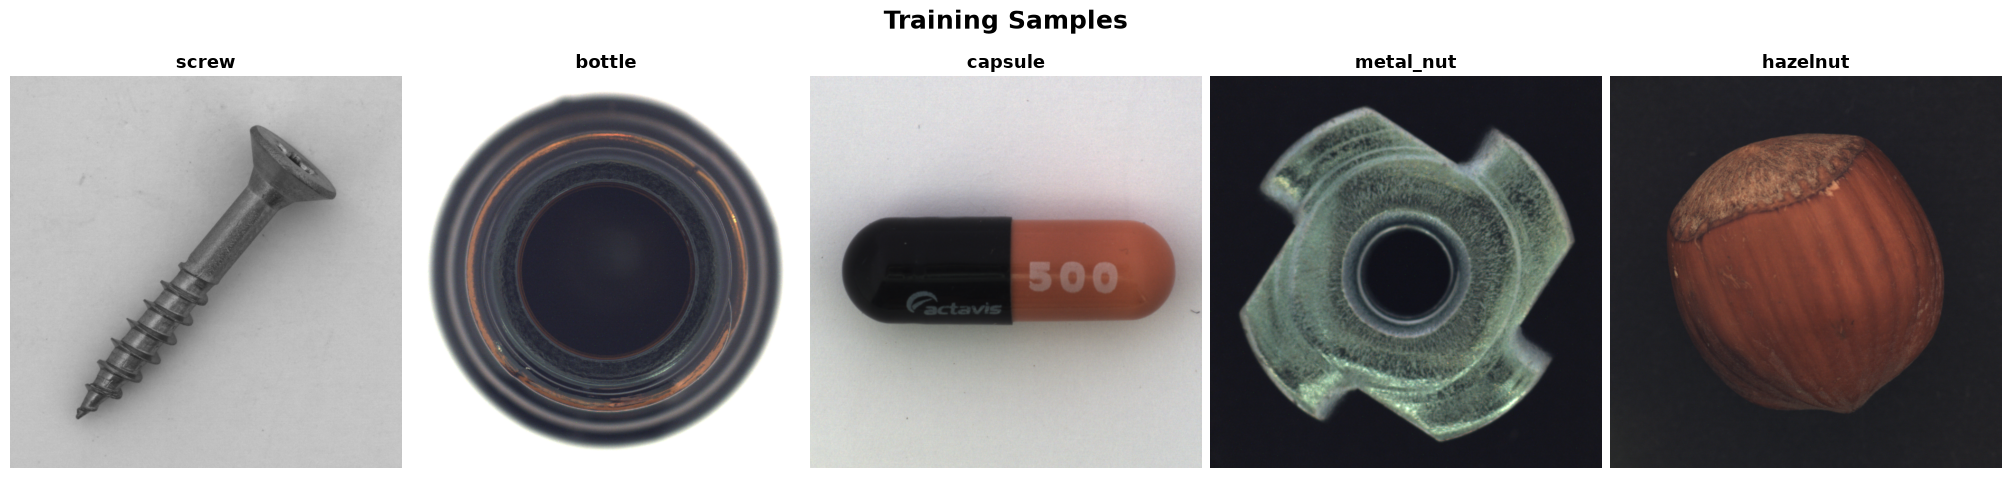

Saved visualization: training_samples


In [29]:
fig, axes = plt.subplots(
    1,
    len(CATEGORIES),
    figsize=(20, 5),
    constrained_layout=True
)

axes = np.atleast_1d(axes)

for axis, category in zip(
    axes,
    CATEGORIES
):
    images = iter_image_files(
        PREPARED_DATASET
        / category
        / "train"
    )

    axis.set_title(
        category,
        fontsize=13,
        fontweight="bold"
    )

    if not images:
        axis.text(
            0.5,
            0.5,
            "No image",
            ha="center",
            va="center"
        )
        axis.axis("off")
        continue

    try:
        axis.imshow(
            read_rgb(images[0])
        )
        axis.axis("off")
    except Exception as error:
        axis.text(
            0.5,
            0.5,
            f"Load failed\n{type(error).__name__}",
            ha="center",
            va="center"
        )
        axis.axis("off")

fig.suptitle(
    "Training Samples",
    fontsize=18,
    fontweight="bold"
)

plt.show()

save_matplotlib_figure(
    fig,
    "Training Samples"
)

## Normal and Defective Gallery

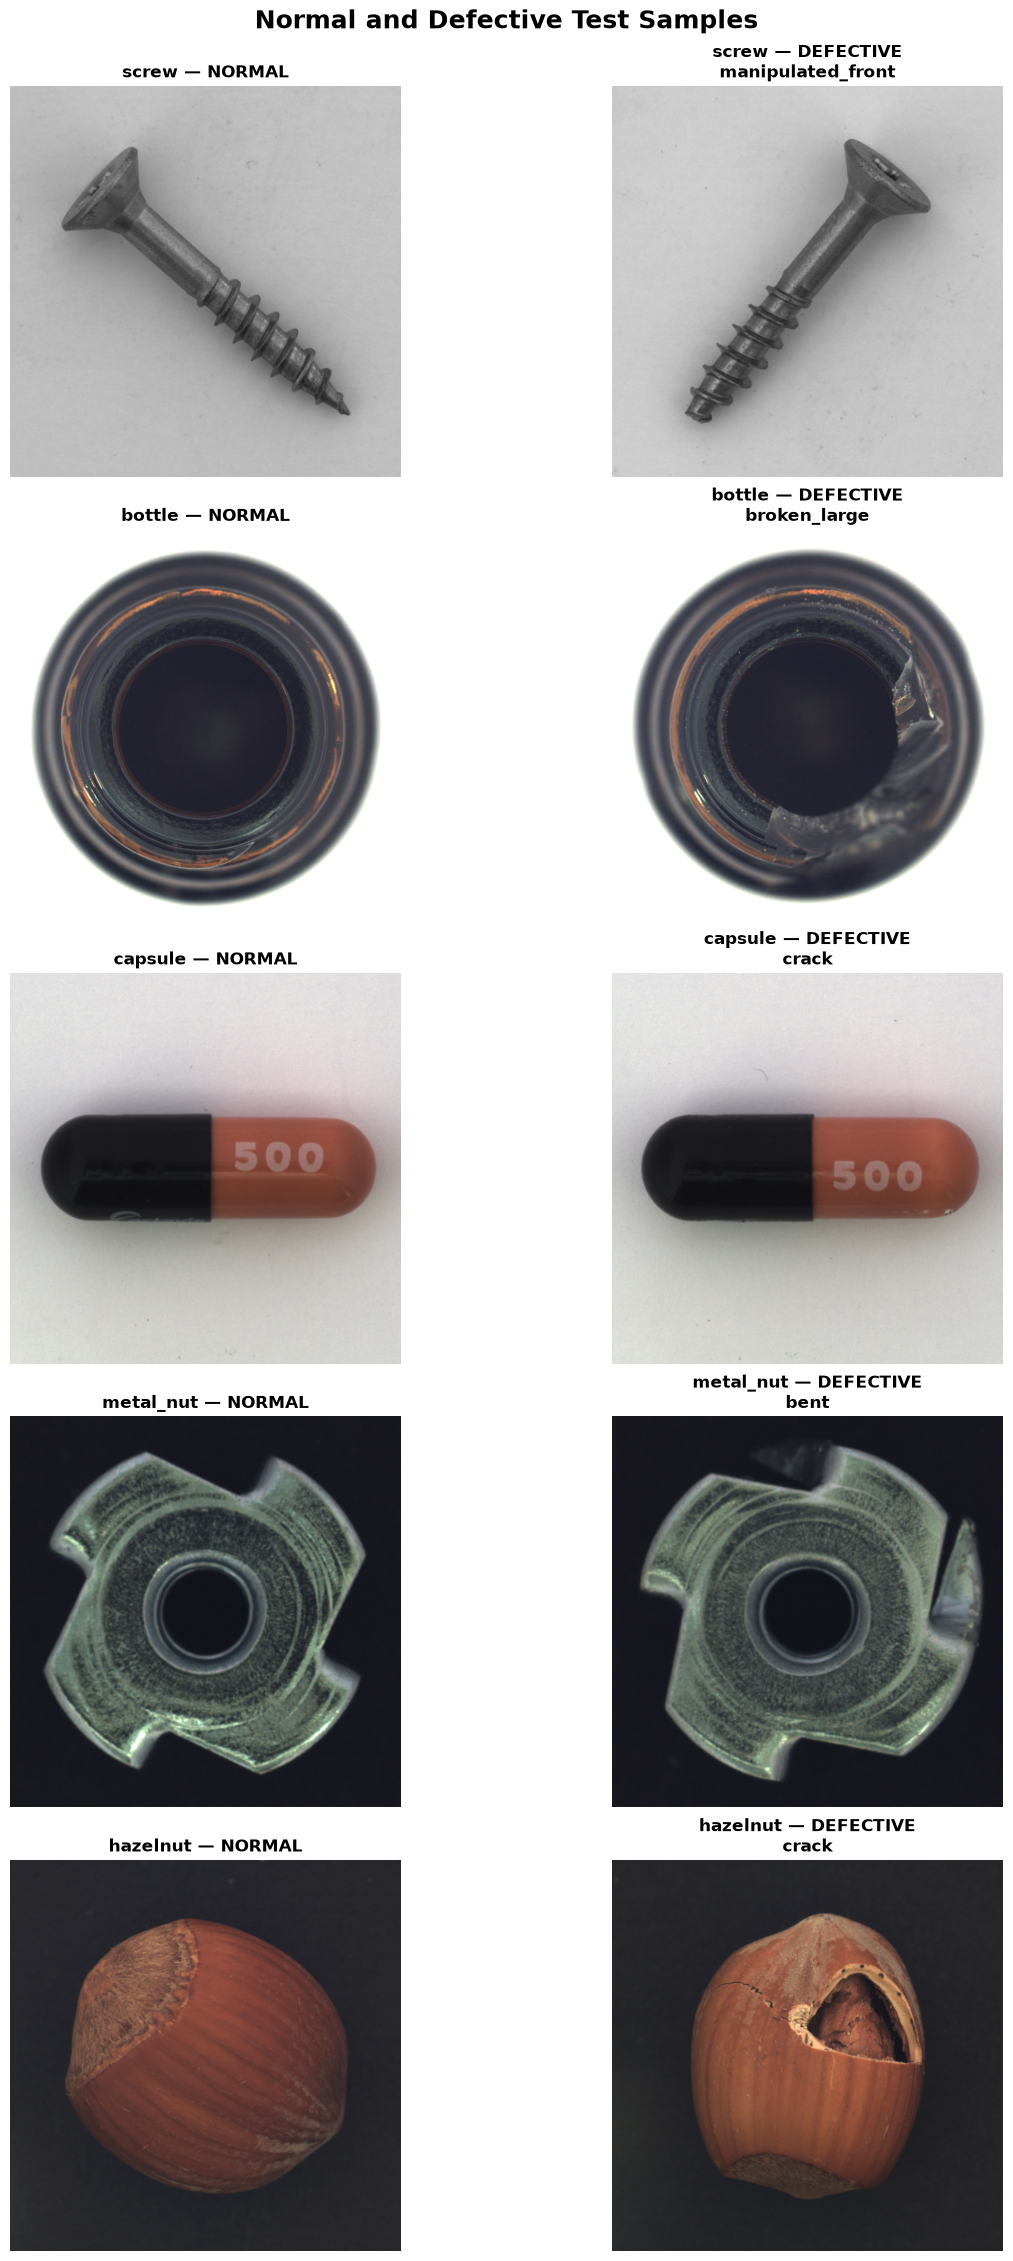

Saved visualization: normal_and_defective_test_samples


In [30]:
fig, axes = plt.subplots(
    len(CATEGORIES),
    2,
    figsize=(12, 4.5 * len(CATEGORIES)),
    constrained_layout=True
)

axes = np.atleast_2d(axes)

for row_index, record in enumerate(sample_rows):
    normal_axis = axes[row_index, 0]
    defective_axis = axes[row_index, 1]

    normal_axis.set_title(
        f"{record['Category']} — NORMAL",
        fontweight="bold"
    )

    defective_axis.set_title(
        f"{record['Category']} — DEFECTIVE\n"
        f"{record['Defect Type'] or 'Unavailable'}",
        fontweight="bold"
    )

    if record["Normal Image"] is not None:
        try:
            normal_axis.imshow(
                read_rgb(record["Normal Image"])
            )
        except Exception as error:
            normal_axis.text(
                0.5,
                0.5,
                f"Load failed\n{type(error).__name__}",
                ha="center",
                va="center"
            )
    else:
        normal_axis.text(
            0.5,
            0.5,
            "Image unavailable",
            ha="center",
            va="center"
        )

    if record["Defective Image"] is not None:
        try:
            defective_axis.imshow(
                read_rgb(record["Defective Image"])
            )
        except Exception as error:
            defective_axis.text(
                0.5,
                0.5,
                f"Load failed\n{type(error).__name__}",
                ha="center",
                va="center"
            )
    else:
        defective_axis.text(
            0.5,
            0.5,
            "Image unavailable",
            ha="center",
            va="center"
        )

    normal_axis.axis("off")
    defective_axis.axis("off")

fig.suptitle(
    "Normal and Defective Test Samples",
    fontsize=18,
    fontweight="bold"
)

plt.show()

save_matplotlib_figure(
    fig,
    "Normal and Defective Test Samples"
)

## Ground-Truth Matching

In [31]:
def ground_truth_images(category):
    return iter_image_files(
        PREPARED_DATASET
        / category
        / "ground_truth"
    )


def match_ground_truth(category, image_path):
    if image_path is None:
        return None

    stem = Path(image_path).stem
    masks = ground_truth_images(category)

    exact_matches = [
        mask
        for mask in masks
        if mask.stem == stem
    ]

    if exact_matches:
        return exact_matches[0]

    prefix_matches = [
        mask
        for mask in masks
        if mask.stem.casefold().startswith(
            stem.casefold()
        )
    ]

    return prefix_matches[0] if prefix_matches else None


for record in sample_rows:
    record["Ground Truth Mask"] = match_ground_truth(
        record["Category"],
        record["Defective Image"]
    )

sample_df = pd.DataFrame(sample_rows)

display(
    sample_df[
        [
            "Category",
            "Defect Type"
        ]
    ]
)

,Category,Defect Type
0,screw,manipulated_front
1,bottle,broken_large
2,capsule,crack
3,metal_nut,bent
4,hazelnut,crack


## Defective Image, Mask, and Overlay Gallery

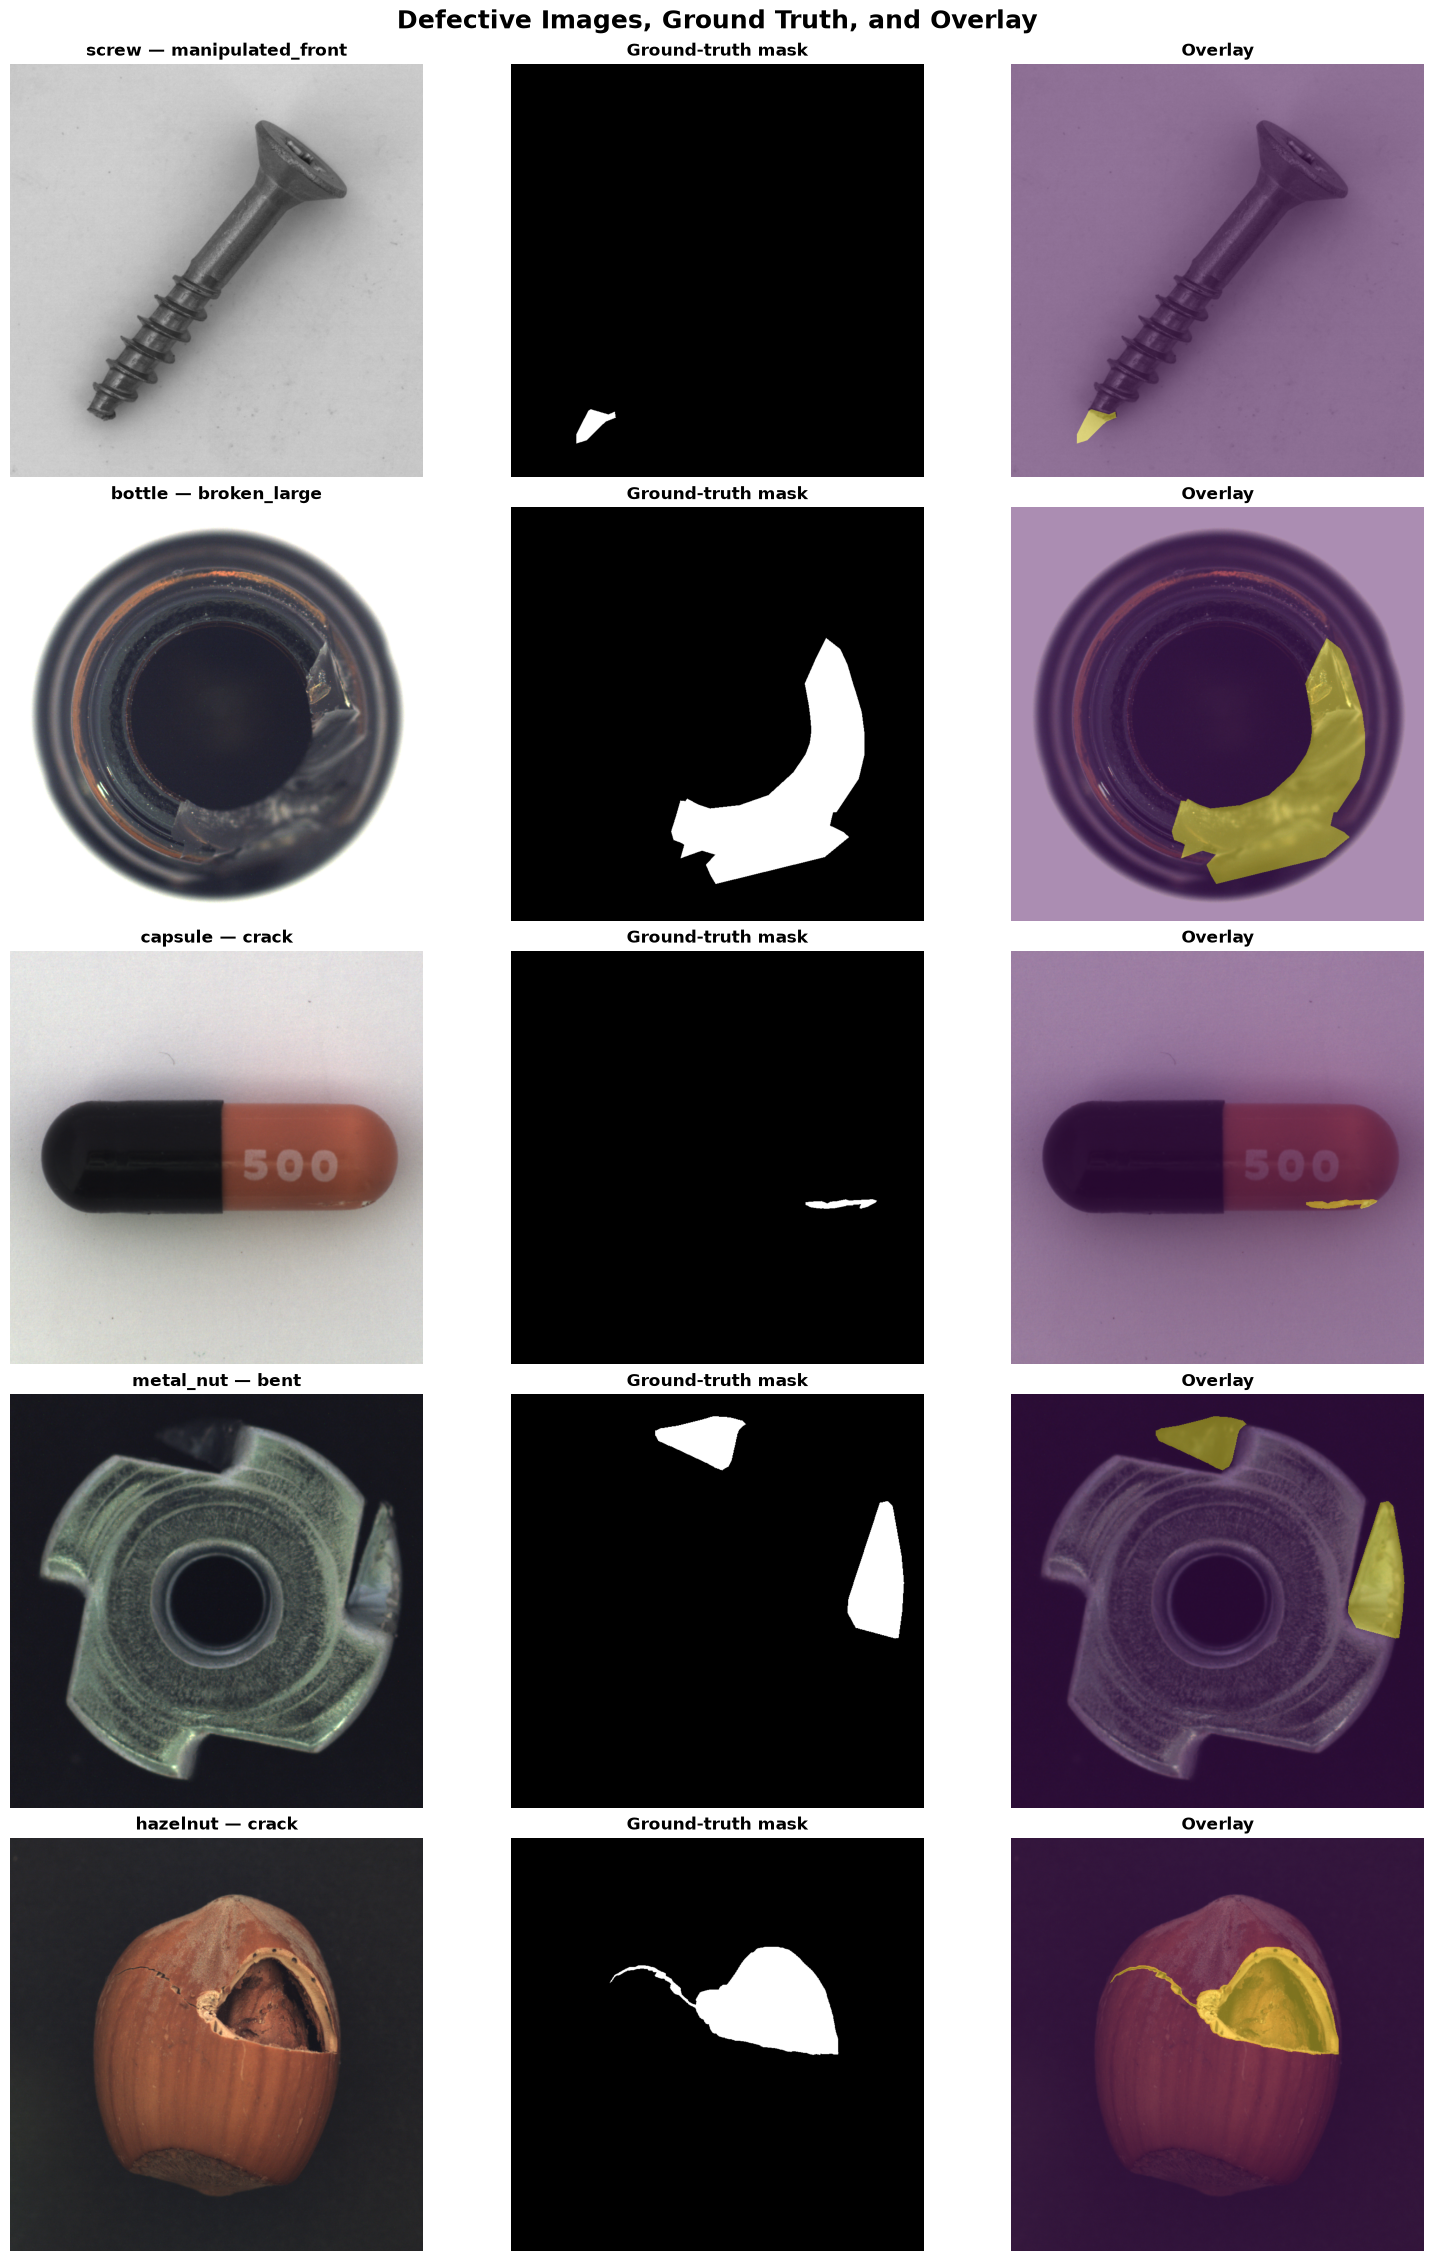

Saved visualization: defective_images_ground_truth_and_overlay


In [32]:
fig, axes = plt.subplots(
    len(CATEGORIES),
    3,
    figsize=(15, 4.5 * len(CATEGORIES)),
    constrained_layout=True
)

axes = np.atleast_2d(axes)

for row_index, record in enumerate(sample_rows):
    image_axis = axes[row_index, 0]
    mask_axis = axes[row_index, 1]
    overlay_axis = axes[row_index, 2]

    image_axis.set_title(
        f"{record['Category']} — "
        f"{record['Defect Type'] or 'Unavailable'}",
        fontweight="bold"
    )

    mask_axis.set_title(
        "Ground-truth mask",
        fontweight="bold"
    )

    overlay_axis.set_title(
        "Overlay",
        fontweight="bold"
    )

    image_data = None
    mask_data = None

    if record["Defective Image"] is not None:
        try:
            image_data = np.asarray(
                read_rgb(
                    record["Defective Image"]
                )
            )
            image_axis.imshow(image_data)
        except Exception as error:
            image_axis.text(
                0.5,
                0.5,
                f"Load failed\n{type(error).__name__}",
                ha="center",
                va="center"
            )
    else:
        image_axis.text(
            0.5,
            0.5,
            "Defective image unavailable",
            ha="center",
            va="center"
        )

    if record["Ground Truth Mask"] is not None:
        try:
            mask_data = np.asarray(
                read_gray(
                    record["Ground Truth Mask"]
                )
            )
            mask_axis.imshow(
                mask_data,
                cmap="gray"
            )
        except Exception as error:
            mask_axis.text(
                0.5,
                0.5,
                f"Mask load failed\n{type(error).__name__}",
                ha="center",
                va="center"
            )
    else:
        mask_axis.text(
            0.5,
            0.5,
            "Ground-truth mask unavailable",
            ha="center",
            va="center"
        )

    if (
        image_data is not None
        and mask_data is not None
        and image_data.shape[:2]
        == mask_data.shape[:2]
    ):
        overlay_axis.imshow(image_data)
        overlay_axis.imshow(
            mask_data > 0,
            alpha=0.45
        )
    else:
        overlay_axis.text(
            0.5,
            0.5,
            "Overlay unavailable",
            ha="center",
            va="center"
        )

    image_axis.axis("off")
    mask_axis.axis("off")
    overlay_axis.axis("off")

fig.suptitle(
    "Defective Images, Ground Truth, and Overlay",
    fontsize=18,
    fontweight="bold"
)

plt.show()

save_matplotlib_figure(
    fig,
    "Defective Images Ground Truth and Overlay"
)

## Full Image Audit

In [33]:
def audit_image(path):
    try:
        with Image.open(path) as image:
            width, height = image.size
            mode = image.mode

        return {
            "Valid": True,
            "Width": width,
            "Height": height,
            "Mode": mode,
            "Error": "",
        }

    except (
        UnidentifiedImageError,
        OSError,
        ValueError
    ) as error:
        return {
            "Valid": False,
            "Width": np.nan,
            "Height": np.nan,
            "Mode": None,
            "Error": safe_error_message(error),
        }


audit_rows = []

for category in CATEGORIES:
    for image_path in iter_image_files(
        PREPARED_DATASET / category
    ):
        result = audit_image(image_path)

        audit_rows.append({
            "Category": category,
            "File": image_path.name,
            "Extension": image_path.suffix.lower(),
            **result,
        })

audit_df = pd.DataFrame(audit_rows)

print(
    f"Images audited: {len(audit_df):,}"
)

if not audit_df.empty:
    print(
        f"Valid images: "
        f"{int(audit_df['Valid'].sum()):,}"
    )
    print(
        f"Invalid images: "
        f"{int((~audit_df['Valid']).sum()):,}"
    )

invalid_df = audit_df[
    ~audit_df["Valid"]
].copy()

if not invalid_df.empty:
    display(invalid_df)
else:
    print("No invalid or unreadable images were detected.")

Images audited: 2,413
Valid images: 2,413
Invalid images: 0
No invalid or unreadable images were detected.


## Image Dimensions

In [34]:
valid_audit_df = audit_df[
    audit_df["Valid"]
].copy()

dimension_df = (
    valid_audit_df
    .groupby(
        [
            "Category",
            "Width",
            "Height"
        ]
    )
    .size()
    .reset_index(name="Images")
)

if not dimension_df.empty:
    fig = px.scatter(
        dimension_df,
        x="Width",
        y="Height",
        size="Images",
        color="Category",
        hover_data=["Images"],
        title="Image Dimensions by Category",
        labels={
            "Width": "Width (pixels)",
            "Height": "Height (pixels)"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=620,
        title_x=0.5
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Image Dimensions by Category",
        width=1400,
        height=850
    )

Plotly PNG export failed: RuntimeError
Saved visualization: image_dimensions_by_category


## Image Aspect Ratio

In [35]:
if not valid_audit_df.empty:
    valid_audit_df["Aspect Ratio"] = (
        valid_audit_df["Width"]
        / valid_audit_df["Height"]
    )

    fig = px.box(
        valid_audit_df,
        x="Category",
        y="Aspect Ratio",
        color="Category",
        points=False,
        title="Image Aspect Ratio Distribution",
        labels={
            "Aspect Ratio": "Width / Height"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=580,
        title_x=0.5,
        showlegend=False
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Image Aspect Ratio Distribution",
        width=1200,
        height=780
    )

Plotly PNG export failed: RuntimeError
Saved visualization: image_aspect_ratio_distribution


## Image Width Distribution

In [36]:
if not valid_audit_df.empty:
    fig = px.histogram(
        valid_audit_df,
        x="Width",
        color="Category",
        marginal="box",
        nbins=35,
        title="Image Width Distribution",
        labels={
            "Width": "Width (pixels)"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=620,
        title_x=0.5
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Image Width Distribution",
        width=1400,
        height=850
    )

Plotly PNG export failed: RuntimeError
Saved visualization: image_width_distribution


## Image Height Distribution

In [37]:
if not valid_audit_df.empty:
    fig = px.histogram(
        valid_audit_df,
        x="Height",
        color="Category",
        marginal="box",
        nbins=35,
        title="Image Height Distribution",
        labels={
            "Height": "Height (pixels)"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=620,
        title_x=0.5
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Image Height Distribution",
        width=1400,
        height=850
    )

Plotly PNG export failed: RuntimeError
Saved visualization: image_height_distribution


## File Extension Distribution

In [38]:
extension_df = (
    audit_df
    .groupby(
        [
            "Category",
            "Extension"
        ]
    )
    .size()
    .reset_index(name="Images")
)

if not extension_df.empty:
    fig = px.bar(
        extension_df,
        x="Category",
        y="Images",
        color="Extension",
        barmode="stack",
        text_auto=True,
        title="Image File Extension Distribution",
        labels={
            "Images": "Number of files"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=560,
        title_x=0.5
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Image File Extension Distribution",
        width=1200,
        height=760
    )

Plotly PNG export failed: RuntimeError
Saved visualization: image_file_extension_distribution


## Color Mode Distribution

In [39]:
mode_df = (
    valid_audit_df
    .groupby(
        [
            "Category",
            "Mode"
        ]
    )
    .size()
    .reset_index(name="Images")
)

if not mode_df.empty:
    fig = px.bar(
        mode_df,
        x="Category",
        y="Images",
        color="Mode",
        barmode="stack",
        text_auto=True,
        title="Image Color Mode Distribution",
        labels={
            "Images": "Number of images"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=560,
        title_x=0.5
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Image Color Mode Distribution",
        width=1200,
        height=760
    )

Plotly PNG export failed: RuntimeError
Saved visualization: image_color_mode_distribution


## Pixel Statistics

In [40]:
def pixel_statistics(path):
    try:
        image = np.asarray(
            read_rgb(path),
            dtype=np.float32
        )

        return {
            "Mean Pixel": float(image.mean()),
            "Std Pixel": float(image.std()),
            "Min Pixel": float(image.min()),
            "Max Pixel": float(image.max()),
        }
    except Exception:
        return None


pixel_rows = []

for category in CATEGORIES:
    training_images = iter_image_files(
        PREPARED_DATASET
        / category
        / "train"
    )

    selected_images = training_images[
        :min(50, len(training_images))
    ]

    for image_path in selected_images:
        stats = pixel_statistics(image_path)

        if stats is None:
            continue

        pixel_rows.append({
            "Category": category,
            "File": image_path.name,
            **stats,
        })

pixel_stats_df = pd.DataFrame(pixel_rows)

display(
    pixel_stats_df.head(20)
)

,Category,File,Mean Pixel,Std Pixel,Min Pixel,Max Pixel
0,screw,000.png,176.720413,32.828663,30.0,210.0
1,screw,001.png,194.906204,37.658745,25.0,235.0
2,screw,002.png,194.322327,38.514114,28.0,234.0
3,screw,003.png,182.873367,34.141582,29.0,251.0
4,screw,004.png,183.909470,31.127703,36.0,217.0
5,screw,005.png,192.430298,36.342625,36.0,230.0
6,screw,006.png,184.099045,34.572453,28.0,216.0
7,screw,007.png,183.123550,33.518368,36.0,215.0
8,screw,008.png,183.047928,34.299923,29.0,216.0
9,screw,009.png,181.873169,33.940430,32.0,214.0


## Plotly — Mean Pixel Intensity

In [41]:
if not pixel_stats_df.empty:
    fig = px.box(
        pixel_stats_df,
        x="Category",
        y="Mean Pixel",
        color="Category",
        points=False,
        title="Mean Pixel Intensity",
        labels={
            "Mean Pixel": "Mean RGB intensity"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=560,
        title_x=0.5,
        showlegend=False
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Mean Pixel Intensity",
        width=1200,
        height=760
    )

Plotly PNG export failed: RuntimeError
Saved visualization: mean_pixel_intensity


## Plotly — Pixel Variation

In [42]:
if not pixel_stats_df.empty:
    fig = px.box(
        pixel_stats_df,
        x="Category",
        y="Std Pixel",
        color="Category",
        points=False,
        title="Pixel Intensity Variation",
        labels={
            "Std Pixel": "Pixel standard deviation"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=560,
        title_x=0.5,
        showlegend=False
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Pixel Intensity Variation",
        width=1200,
        height=760
    )

Plotly PNG export failed: RuntimeError
Saved visualization: pixel_intensity_variation


## Plotly — Minimum and Maximum Pixel Intensity

In [43]:
if not pixel_stats_df.empty:
    range_df = pixel_stats_df.melt(
        id_vars="Category",
        value_vars=[
            "Min Pixel",
            "Max Pixel"
        ],
        var_name="Statistic",
        value_name="Intensity",
    )

    fig = px.box(
        range_df,
        x="Category",
        y="Intensity",
        color="Statistic",
        title="Minimum and Maximum Pixel Intensities",
        labels={
            "Intensity": "Pixel intensity"
        },
        template="plotly_white",
    )

    fig.update_layout(
        height=560,
        title_x=0.5
    )

    fig.show()

    save_plotly_figure(
        fig,
        "Minimum and Maximum Pixel Intensities",
        width=1200,
        height=760
    )

Plotly PNG export failed: RuntimeError
Saved visualization: minimum_and_maximum_pixel_intensities


## Final Dataset Verification

In [44]:
final_rows = []

for category in CATEGORIES:
    root = PREPARED_DATASET / category

    train = root / "train"
    test = root / "test"
    ground_truth = root / "ground_truth"

    final_rows.append({
        "Category": category,
        "Prepared": root.is_dir(),
        "Train": train.is_dir(),
        "Test": test.is_dir(),
        "Ground Truth": ground_truth.is_dir(),
        "Train Images": count_images(train),
        "Test Images": count_images(test),
        "Ground Truth Masks": count_images(ground_truth),
    })

final_df = pd.DataFrame(final_rows)

display(final_df)

,Category,Prepared,Train,Test,Ground Truth,Train Images,Test Images,Ground Truth Masks
0,screw,True,True,True,True,320,160,119
1,bottle,True,True,True,True,209,83,63
2,capsule,True,True,True,True,219,132,109
3,metal_nut,True,True,True,True,220,115,93
4,hazelnut,True,True,True,True,391,110,70


## Final Validation Chart

In [45]:
final_chart_df = (
    final_df[
        [
            "Category",
            "Prepared",
            "Train",
            "Test",
            "Ground Truth"
        ]
    ]
    .set_index("Category")
    .astype(int)
)

fig = px.imshow(
    final_chart_df,
    text_auto=True,
    aspect="auto",
    title="Final VisionGuard AI Dataset Validation",
    labels={
        "x": "Validation",
        "y": "Category",
        "color": "Status"
    },
    template="plotly_white",
)

fig.update_layout(
    height=500,
    title_x=0.5
)

fig.show()

save_plotly_figure(
    fig,
    "Final VisionGuard AI Dataset Validation",
    width=1200,
    height=700
)

Plotly PNG export failed: RuntimeError
Saved visualization: final_visionguard_ai_dataset_validation


## Final Status

In [46]:
prepared_categories = final_df.loc[
    final_df["Prepared"],
    "Category"
].tolist()

invalid_categories = final_df.loc[
    ~(
        final_df["Prepared"]
        & final_df["Train"]
        & final_df["Test"]
        & final_df["Ground Truth"]
    ),
    "Category"
].tolist()

print("=" * 64)

if (
    not missing_categories
    and not invalid_categories
):
    print(
        "VisionGuard AI dataset preparation "
        "completed successfully."
    )
else:
    print(
        "VisionGuard AI dataset preparation "
        "completed with warnings."
    )

print()
print("Prepared categories:")

for category in prepared_categories:
    print(category)

if missing_categories:
    print()
    print("Missing categories:")

    for category in missing_categories:
        print(category)

if invalid_categories:
    print()
    print("Categories with invalid structure:")

    for category in invalid_categories:
        print(category)

print()
print(
    f"Saved visualizations: {len(list(IMAGE_FOLDER.glob('*.png')))}"
)
print("=" * 64)

VisionGuard AI dataset preparation completed successfully.

Prepared categories:
screw
bottle
capsule
metal_nut
hazelnut

Saved visualizations: 3


## Reusable Variables

In [47]:
saved_images = sorted(
    IMAGE_FOLDER.glob("*.png"),
    key=lambda item: item.name.casefold()
)

image_index_df = pd.DataFrame({
    "Visualization": [
        item.stem.replace("_", " ").title()
        for item in saved_images
    ]
})

print(f"Visualizations saved: {len(image_index_df)}")
display(image_index_df)


Visualizations saved: 3


,Visualization
0,Defective Images Ground Truth And Overlay
1,Normal And Defective Test Samples
2,Training Samples


In [48]:
DATASET_ROOT = PREPARED_DATASET
CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut",
]

print("Reusable variables are ready.")
print("Categories:", ", ".join(CATEGORIES))
print("summary_df rows:", len(summary_df))

Reusable variables are ready.
Categories: screw, bottle, capsule, metal_nut, hazelnut
summary_df rows: 5


## Output

All charts and visual galleries generated by this notebook are automatically saved as PNG files using their chart titles as filenames.

Filesystem details remain internal and are not displayed in notebook output.

The resulting variables can be reused by the next VisionGuard AI notebooks.